# Long sandwich cylinders under hydrostatic pressure: Han, Kardomateas and Simitses (2004)

J.-H. Han, G. A. Kardomateas and G. J. Simitses, *Elasticity, shell theory and finite element results for the buckling of long sandwich cylindrical shells under external pressure*, Composites Part B 35 (2004) 591-598, https://doi.org/10.1016/j.compositesb.2003.07.002.

Sandwich rings (long cylinders) under a uniform external hydrostatic pressure $p$ acting on the outer surface $R_2$, the inner surface being free, which remains normal to the deflected surface, mode $n = 2$:

- core $c = 25.4$ mm (1 in), faces $f = 2.54$ mm (0.1 in), $h = 2f + c = 30.48$ mm, width $B = 76.2$ mm, $R_0$ the mean radius, $R_0/h$ = 15, 30, 60 and 120 (Table 2), and the thicker faces $f = 0.3$ in, $c = 0.6$ in (Table 3);
- Table 1: faces of boron/epoxy, graphite/epoxy or kevlar/epoxy, with the fibres along the hoop direction, and an isotropic alloy-foam core;
- references: the 3D elasticity solution, the classical shell formula, Eq. (12), $p_{cl} = 3 (EI)_{eq}/(B R_0^3)$, the shear deformable shell formula, Eq. (13a), $p = p_{cl}/(1 + 4 k_s)$ with $k_s = (EI)_{eq}/(C R_0^2)$, where $C$ is the transverse shear stiffness of the core only, Eq. (14a), or of the effective modulus $\bar{G}$, Eqs. (14b, 14c), and the finite elements S8R and C3D20R of ABAQUS (Table 4).

The data of the tables are in `tests/tests_shell/test_follower_pressure_validation.py`.

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

import follower_utils as fu
from follower_utils import val, fmt, pct, markdown_table

# True runs panels again, otherwise the results saved in RESULTS are loaded
RERUN = False
RESULTS = 'results'

## panels model

A long cylinder under a uniform pressure buckles as a ring, in generalized plane strain, with the mode $w = \cos(n\theta)$, $n = 2$. The ring is modelled by `val.ring_shell`, a quarter of the circumference, $b = \pi R/2$, of a cylindrical shell with Sanders' kinematics:

- symmetry planes at the straight edges, $v = 0$ and $w_{,y} = 0$ (and $\phi_y = 0$ for the FSDT and TSDT), which contain the ring modes $n = 2, 4, \ldots$;
- symmetry planes at the ends, $u = 0$, $v_{,x} = w_{,x} = 0$, i.e. generalized plane strain;
- 4 terms along $x$ and 15 along $y$.

The pressure is a follower pressure, `add_pressure_load(-1., follower=True, cte=False, zp=zp)`, with `zp` the position of the loaded surface: `zp = h/2` places it on the outer surface, as in the elasticity solution, applied as $p(1 + z_p/R)$ per unit mid-surface area (shallow shell). The prestress comes from a linear static analysis, and the critical pressure from `val.ring_buckling_pressure`:

```python
c0 = solve(k0, s.calc_fext())
lb(k0, s.calc_kG(c=c0) + s.calc_kCfollower())
```

The fibres of the faces are along the hoop direction, i.e. plies at 90 deg, with `laminaprop = (E11, E22, nu12, G12, G13, G23) = (E2, E3, nu23, G23, G12, G31)` in the notation of the reference (1 = r, 2 = $\theta$, 3 = z): $G_{13}$ of the ply, the transverse shear stiffness `A44` of the ring, is the $r\theta$ modulus $G_{12}$ of the reference.

## The shell formulas

The formulas of Eqs. (12)-(14) are evaluated with the data of Table 1, `val.han_shell_formulas`. With the core shear modulus $G_c = E_c/(2(1 + \nu_c)) = 0.017256$ GPa, which Table 1 rounds to 0.0173 GPa, they reproduce the three shell columns of Tables 2 and 3 within $5 \times 10^{-5}$:

In [2]:
rows = []
for face in val.FACES:
    for i, ratio in enumerate(val.RATIOS):
        ref = (val.HAN2004_CLASSICAL[face][i],) + val.HAN2004[face][i][1:3]
        calc = val.han_shell_formulas(face, ratio)
        rows.append([face, ratio] + ['%s / %s' % (fmt(r), fmt(c)) for r, c in zip(ref, calc)])
f3, c3 = 0.3*val.INCH, 0.6*val.INCH
for ratio, elast, classical, core_only, gbar in val.HAN2004_TABLE3:
    calc = val.han_shell_formulas('graphite', ratio, f3, c3)
    rows.append(['graphite, Table 3', ratio] + ['%s / %s' % (fmt(r), fmt(c)) for r, c in
                                                zip((classical, core_only, gbar), calc)])
display(Markdown(markdown_table(['faces', '$R_0/h$', 'classical (Pa): paper / formula',
                                 'core only: paper / formula', '$\\bar{G}$: paper / formula'], rows)))

| faces | $R_0/h$ | classical (Pa): paper / formula | core only: paper / formula | $\bar{G}$: paper / formula |
|---|---|---|---|---|
| boron | 15 | 6,898,740 / 6,898,744 | 651,125 / 651,125 | 899,768 / 899,768 |
| boron | 30 | 862,343 / 862,343 | 253,721 / 253,721 | 323,361 / 323,361 |
| boron | 60 | 107,793 / 107,793 | 67,383 / 67,383 | 76,087 / 76,087 |
| boron | 120 | 13,474 / 13,474 | 11,717 / 11,717 | 12,203 / 12,203 |
| graphite | 15 | 5,650,460 / 5,650,459 | 637,826 / 637,826 | 874,654 / 874,654 |
| graphite | 30 | 706,307 / 706,307 | 238,236 / 238,236 | 298,643 / 298,643 |
| graphite | 60 | 88,288 / 88,288 | 59,207 / 59,207 | 65,825 / 65,825 |
| graphite | 120 | 11,036 / 11,036 | 9,829 / 9,829 | 10,168 / 10,169 |
| kevlar | 15 | 2,370,590 / 2,370,589 | 551,668 / 551,668 | 719,856 / 719,856 |
| kevlar | 30 | 296,324 / 296,324 | 162,433 / 162,433 | 188,347 / 188,347 |
| kevlar | 60 | 37,040 / 37,040 | 30,712 / 30,712 | 32,397 / 32,397 |
| kevlar | 120 | 4,630 / 4,630 | 4,403 / 4,403 | 4,470 / 4,470 |
| graphite, Table 3 | 15 | 11,731,900 / 11,731,906 | 416,091 / 416,091 | 1,501,160 / 1,501,157 |
| graphite, Table 3 | 30 | 1,466,490 / 1,466,488 | 188,038 / 188,038 | 542,378 / 542,378 |
| graphite, Table 3 | 60 | 183,311 / 183,311 | 67,900 / 67,900 | 128,553 / 128,553 |
| graphite, Table 3 | 120 | 22,914 / 22,914 | 16,081 / 16,081 | 20,709 / 20,709 |

## panels runs

For each case:

- `CLPT`: the classical laminated plate theory, against the classical formula;
- `FSDT core`, `FSDT Gbar`: the FSDT with the transverse shear stiffness `A44` set to the $C/B$ of the formulas, through a float `fsdt_shear_correction`, against the shear deformable formulas;
- `FSDT rohwer`, `FSDT vlachoutsis`, `FSDT 5/6`: the FSDT with the shear correction methods of `composites`, `Shell.fsdt_shear_correction = 'rohwer'` (the default), `'vlachoutsis'` and `5/6`;
- `TSDT`: the third-order theory of Reddy, without shear correction;

all of them with the pressure on the mid-surface (`zp = 0`), as in the shell formulas, and the last four also on the outer surface (`zp = h/2`), as in the elasticity solution.

In [3]:
ring_case = fu.sandwich_ring_case


def compute():
    res = {}
    for face in val.FACES:
        for ratio in val.RATIOS:
            res['%s %d' % (face, ratio)] = ring_case(face, ratio)
    for ratio, *_ in val.HAN2004_TABLE3:
        res['table3 %d' % ratio] = ring_case('graphite', ratio, f=0.3*val.INCH, c=0.6*val.INCH)
    return res


res = fu.run_or_load(os.path.join(RESULTS, 'han2004_sandwich_rings.json'), compute, rerun=RERUN)

### Table 2: panels against the shell formulas

The FSDT with the shear stiffness of each formula is the shear deformable formula in the inextensional limit, see `theory/shells/follower_pressure/follower_pressure.md`. The remaining differences are the plane-strain factor $1/(1 - \nu_{12}\nu_{21})$ of the bending stiffness, which the formulas omit (0.5% for boron/epoxy, less for the others), and the extensibility of the ring.

In [4]:
rows = []
for face in val.FACES:
    for i, ratio in enumerate(val.RATIOS):
        r = res['%s %d' % (face, ratio)]
        cl = val.HAN2004_CLASSICAL[face][i]
        elast, core_only, gbar = val.HAN2004[face][i][:3]
        rows.append([face, ratio, fmt(cl), fmt(r['CLPT'], percent=pct(r['CLPT'], cl)),
                     fmt(core_only), fmt(r['FSDT core'], percent=pct(r['FSDT core'], core_only)),
                     fmt(gbar), fmt(r['FSDT Gbar'], percent=pct(r['FSDT Gbar'], gbar))])
display(Markdown(markdown_table(['faces', '$R_0/h$', 'classical, Eq. (12)', 'panels CLPT',
                                 'core only, Eq. (14a)', 'panels FSDT core',
                                 '$\\bar{G}$, Eq. (14c)', 'panels FSDT Gbar'], rows)))

| faces | $R_0/h$ | classical, Eq. (12) | panels CLPT | core only, Eq. (14a) | panels FSDT core | $\bar{G}$, Eq. (14c) | panels FSDT Gbar |
|---|---|---|---|---|---|---|---|
| boron | 15 | 6,898,740 | 6,926,848 (+0.4%) | 651,125 | 651,374 (+0.0%) | 899,768 | 900,244 (+0.1%) |
| boron | 30 | 862,343 | 866,463 (+0.5%) | 253,721 | 254,077 (+0.1%) | 323,361 | 323,939 (+0.2%) |
| boron | 60 | 107,793 | 108,327 (+0.5%) | 67,383 | 67,592 (+0.3%) | 76,087 | 76,353 (+0.3%) |
| boron | 120 | 13,474 | 13,541 (+0.5%) | 11,717 | 11,768 (+0.4%) | 12,203 | 12,258 (+0.5%) |
| graphite | 15 | 5,650,460 | 5,670,709 (+0.4%) | 637,826 | 638,083 (+0.0%) | 874,654 | 875,138 (+0.1%) |
| graphite | 30 | 706,307 | 709,336 (+0.4%) | 238,236 | 238,580 (+0.1%) | 298,643 | 299,183 (+0.2%) |
| graphite | 60 | 88,288 | 88,683 (+0.4%) | 59,207 | 59,384 (+0.3%) | 65,825 | 66,044 (+0.3%) |
| graphite | 120 | 11,036 | 11,086 (+0.5%) | 9,829 | 9,869 (+0.4%) | 10,168 | 10,211 (+0.4%) |
| kevlar | 15 | 2,370,590 | 2,388,681 (+0.8%) | 551,668 | 552,642 (+0.2%) | 719,856 | 721,516 (+0.2%) |
| kevlar | 30 | 296,324 | 298,794 (+0.8%) | 162,433 | 163,172 (+0.5%) | 188,347 | 189,342 (+0.5%) |
| kevlar | 60 | 37,040 | 37,356 (+0.9%) | 30,712 | 30,928 (+0.7%) | 32,397 | 32,638 (+0.7%) |
| kevlar | 120 | 4,630 | 4,670 (+0.9%) | 4,403 | 4,439 (+0.8%) | 4,470 | 4,507 (+0.8%) |

### Tables 2 and 4: panels against the elasticity solution and the finite elements

Critical pressure in Pa, with the difference to the elasticity solution in parentheses.

In [5]:
models = ['FSDT rohwer', 'FSDT vlachoutsis', 'FSDT 5/6', 'TSDT']
for zp in ('', ', zp = h/2'):
    rows = []
    for face in val.FACES:
        for i, ratio in enumerate(val.RATIOS):
            r = res['%s %d' % (face, ratio)]
            elast, core_only, gbar, s8r, c3d20 = val.HAN2004[face][i]
            rows.append([face, ratio, fmt(elast), fmt(s8r, percent=pct(s8r, elast)),
                         fmt(c3d20, percent=pct(c3d20, elast))]
                        + [fmt(r[m + zp], percent=pct(r[m + zp], elast)) for m in models])
    display(Markdown('**Pressure on the %s surface**' % ('outer' if zp else 'mid')))
    display(Markdown(markdown_table(['faces', '$R_0/h$', 'elasticity', 'S8R', 'C3D20R']
                                    + ['panels ' + m for m in models], rows)))

**Pressure on the mid surface**

| faces | $R_0/h$ | elasticity | S8R | C3D20R | panels FSDT rohwer | panels FSDT vlachoutsis | panels FSDT 5/6 | panels TSDT |
|---|---|---|---|---|---|---|---|---|
| boron | 15 | 741,773 | 809,208 (+9.1%) | 783,556 (+5.6%) | 776,501 (+4.7%) | 776,498 (+4.7%) | 5,921,676 (+698.3%) | 2,521,080 (+239.9%) |
| boron | 30 | 277,305 | 298,839 (+7.8%) | 287,722 (+3.8%) | 290,610 (+4.8%) | 290,609 (+4.8%) | 831,167 (+199.7%) | 602,475 (+117.3%) |
| boron | 60 | 70,416 | 73,863 (+4.9%) | 72,373 (+2.8%) | 72,437 (+2.9%) | 72,437 (+2.9%) | 107,189 (+52.2%) | 97,625 (+38.6%) |
| boron | 120 | 11,817 | 12,189 (+3.1%) | 12,106 (+2.4%) | 12,049 (+2.0%) | 12,049 (+2.0%) | 13,506 (+14.3%) | 13,180 (+11.5%) |
| graphite | 15 | 720,842 | 790,739 (+9.7%) | 762,926 (+5.8%) | 757,705 (+5.1%) | 757,700 (+5.1%) | 5,097,108 (+607.1%) | 2,567,471 (+256.2%) |
| graphite | 30 | 258,549 | 278,606 (+7.8%) | 268,754 (+3.9%) | 270,517 (+4.6%) | 270,515 (+4.6%) | 689,912 (+166.8%) | 544,451 (+110.6%) |
| graphite | 60 | 61,528 | 64,381 (+4.6%) | 63,244 (+2.8%) | 63,092 (+2.5%) | 63,092 (+2.5%) | 88,063 (+43.1%) | 82,438 (+34.0%) |
| graphite | 120 | 9,918 | 10,184 (+2.7%) | 10,126 (+2.1%) | 10,065 (+1.5%) | 10,065 (+1.5%) | 11,066 (+11.6%) | 10,880 (+9.7%) |
| kevlar | 15 | 605,472 | 673,845 (+11.3%) | 647,488 (+6.9%) | 639,961 (+5.7%) | 639,952 (+5.7%) | 2,085,523 (+244.4%) | 1,117,033 (+84.5%) |
| kevlar | 30 | 171,351 | 184,090 (+7.4%) | 179,624 (+4.8%) | 177,472 (+3.6%) | 177,471 (+3.6%) | 288,309 (+68.3%) | 232,484 (+35.7%) |
| kevlar | 60 | 31,418 | 32,633 (+3.9%) | 32,341 (+2.9%) | 31,903 (+1.5%) | 31,903 (+1.5%) | 37,019 (+17.8%) | 34,868 (+11.0%) |
| kevlar | 120 | 4,476 | 4,533 (+1.3%) | 4,522 (+1.0%) | 4,478 (+0.1%) | 4,478 (+0.1%) | 4,659 (+4.1%) | 4,588 (+2.5%) |

**Pressure on the outer surface**

| faces | $R_0/h$ | elasticity | S8R | C3D20R | panels FSDT rohwer | panels FSDT vlachoutsis | panels FSDT 5/6 | panels TSDT |
|---|---|---|---|---|---|---|---|---|
| boron | 15 | 741,773 | 809,208 (+9.1%) | 783,556 (+5.6%) | 751,453 (+1.3%) | 751,449 (+1.3%) | 5,730,654 (+672.6%) | 2,439,755 (+228.9%) |
| boron | 30 | 277,305 | 298,839 (+7.8%) | 287,722 (+3.8%) | 285,846 (+3.1%) | 285,845 (+3.1%) | 817,541 (+194.8%) | 592,598 (+113.7%) |
| boron | 60 | 70,416 | 73,863 (+4.9%) | 72,373 (+2.8%) | 71,838 (+2.0%) | 71,838 (+2.0%) | 106,303 (+51.0%) | 96,818 (+37.5%) |
| boron | 120 | 11,817 | 12,189 (+3.1%) | 12,106 (+2.4%) | 11,999 (+1.5%) | 11,999 (+1.5%) | 13,450 (+13.8%) | 13,125 (+11.1%) |
| graphite | 15 | 720,842 | 790,739 (+9.7%) | 762,926 (+5.8%) | 733,262 (+1.7%) | 733,258 (+1.7%) | 4,932,685 (+584.3%) | 2,484,650 (+244.7%) |
| graphite | 30 | 258,549 | 278,606 (+7.8%) | 268,754 (+3.9%) | 266,082 (+2.9%) | 266,081 (+2.9%) | 678,602 (+162.5%) | 535,525 (+107.1%) |
| graphite | 60 | 61,528 | 64,381 (+4.6%) | 63,244 (+2.8%) | 62,570 (+1.7%) | 62,570 (+1.7%) | 87,335 (+41.9%) | 81,756 (+32.9%) |
| graphite | 120 | 9,918 | 10,184 (+2.7%) | 10,126 (+2.1%) | 10,023 (+1.1%) | 10,023 (+1.1%) | 11,020 (+11.1%) | 10,835 (+9.2%) |
| kevlar | 15 | 605,472 | 673,845 (+11.3%) | 647,488 (+6.9%) | 619,318 (+2.3%) | 619,309 (+2.3%) | 2,018,248 (+233.3%) | 1,081,000 (+78.5%) |
| kevlar | 30 | 171,351 | 184,090 (+7.4%) | 179,624 (+4.8%) | 174,563 (+1.9%) | 174,561 (+1.9%) | 283,583 (+65.5%) | 228,673 (+33.5%) |
| kevlar | 60 | 31,418 | 32,633 (+3.9%) | 32,341 (+2.9%) | 31,639 (+0.7%) | 31,639 (+0.7%) | 36,713 (+16.9%) | 34,580 (+10.1%) |
| kevlar | 120 | 4,476 | 4,533 (+1.3%) | 4,522 (+1.0%) | 4,460 (-0.4%) | 4,460 (-0.4%) | 4,640 (+3.7%) | 4,569 (+2.1%) |

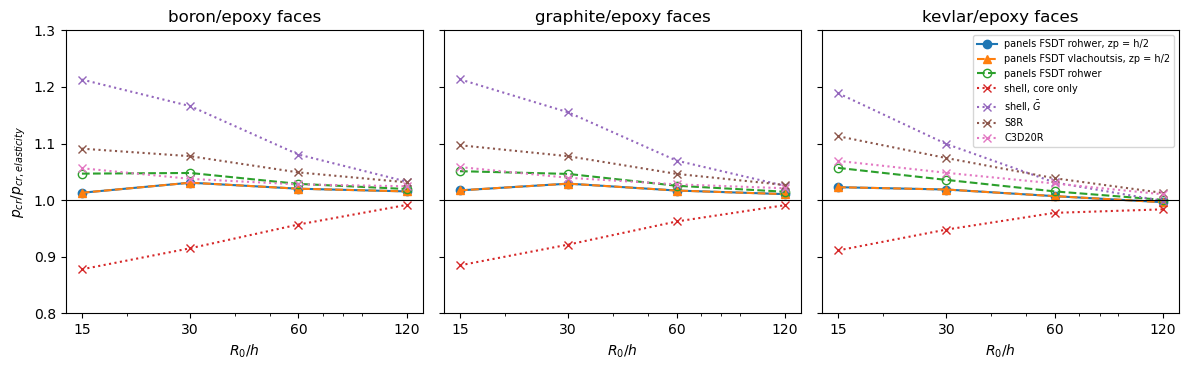

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)
# the FSDT with 5/6 and the TSDT, up to 7.7 and 3.4 times the elasticity solution, are in the tables only
styles = {'FSDT rohwer, zp = h/2': dict(marker='o'), 'FSDT vlachoutsis, zp = h/2': dict(marker='^', ls='--'),
          'FSDT rohwer': dict(marker='o', ls='--', mfc='none')}
for ax, face in zip(axes, val.FACES):
    elast = np.array([row[0] for row in val.HAN2004[face]])
    for label, st in styles.items():
        p = np.array([res['%s %d' % (face, r)][label] for r in val.RATIOS])
        ax.plot(val.RATIOS, p/elast, label='panels ' + label, **st)
    for j, label in ((1, 'shell, core only'), (2, 'shell, $\\bar{G}$'), (3, 'S8R'), (4, 'C3D20R')):
        p = np.array([row[j] for row in val.HAN2004[face]])
        ax.plot(val.RATIOS, p/elast, ls=':', marker='x', label=label)
    ax.axhline(1, color='k', lw=0.8)
    ax.set_ylim(0.8, 1.3)
    ax.set_xscale('log')
    ax.set_xticks(val.RATIOS)
    ax.set_xticklabels(val.RATIOS)
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_title('%s/epoxy faces' % face)
    ax.set_xlabel('$R_0/h$')
axes[0].set_ylabel('$p_{cr}/p_{cr, elasticity}$')
axes[-1].legend(fontsize=7)
plt.tight_layout()

### Table 3: thicker faces

Graphite/epoxy faces $f = 0.3$ in and core $c = 0.6$ in, the same total thickness. The paper gives the elasticity and shell results only.

In [7]:
rows = []
for ratio, elast, classical, core_only, gbar in val.HAN2004_TABLE3:
    r = res['table3 %d' % ratio]
    rows.append([ratio, fmt(elast),
                 '%s / %s' % (fmt(classical, percent=pct(classical, elast)), fmt(r['CLPT'], percent=pct(r['CLPT'], elast))),
                 '%s / %s' % (fmt(core_only, percent=pct(core_only, elast)), fmt(r['FSDT core'], percent=pct(r['FSDT core'], elast))),
                 '%s / %s' % (fmt(gbar, percent=pct(gbar, elast)), fmt(r['FSDT Gbar'], percent=pct(r['FSDT Gbar'], elast)))]
                + [fmt(r[m + ', zp = h/2'], percent=pct(r[m + ', zp = h/2'], elast)) for m in models])
display(Markdown(markdown_table(['$R_0/h$', 'elasticity', 'classical / panels CLPT',
                                 'core only / panels FSDT core', '$\\bar{G}$ / panels FSDT Gbar']
                                + ['panels %s, zp = h/2' % m for m in models], rows)))

| $R_0/h$ | elasticity | classical / panels CLPT | core only / panels FSDT core | $\bar{G}$ / panels FSDT Gbar | panels FSDT rohwer, zp = h/2 | panels FSDT vlachoutsis, zp = h/2 | panels FSDT 5/6, zp = h/2 | panels TSDT, zp = h/2 |
|---|---|---|---|---|---|---|---|---|
| 15 | 1,244,010 | 11,731,900 (+843.1%) / 11,776,901 (+846.7%) | 416,091 (-66.6%) / 416,147 (-66.5%) | 1,501,160 (+20.7%) / 1,501,891 (+20.7%) | 927,098 (-25.5%) | 927,095 (-25.5%) | 10,565,968 (+749.3%) | 9,671,265 (+677.4%) |
| 30 | 393,573 | 1,466,490 (+272.6%) / 1,472,828 (+274.2%) | 188,038 (-52.2%) / 188,142 (-52.2%) | 542,378 (+37.8%) / 543,243 (+38.0%) | 378,773 (-3.8%) | 378,772 (-3.8%) | 1,420,734 (+261.0%) | 1,386,724 (+252.3%) |
| 60 | 105,699 | 183,311 (+73.4%) / 184,126 (+74.2%) | 67,900 (-35.8%) / 68,011 (-35.7%) | 128,553 (+21.6%) / 128,954 (+22.0%) | 107,021 (+1.3%) | 107,020 (+1.3%) | 181,710 (+71.9%) | 180,586 (+70.8%) |
| 120 | 19,297 | 22,914 (+18.7%) / 23,016 (+19.3%) | 16,081 (-16.7%) / 16,131 (-16.4%) | 20,709 (+7.3%) / 20,792 (+7.7%) | 19,481 (+1.0%) | 19,481 (+1.0%) | 22,893 (+18.6%) | 22,857 (+18.4%) |

In [8]:
# summary of the differences to the elasticity solution, Table 2
for m in models:
    d = [pct(res['%s %d' % (face, ratio)][m + ', zp = h/2'], val.HAN2004[face][i][0])
         for face in val.FACES for i, ratio in enumerate(val.RATIOS)]
    print('%-18s zp = h/2: %+.1f%% to %+.1f%%' % (m, min(d), max(d)))

FSDT rohwer        zp = h/2: -0.4% to +3.1%
FSDT vlachoutsis   zp = h/2: -0.4% to +3.1%
FSDT 5/6           zp = h/2: +3.7% to +672.6%
TSDT               zp = h/2: +2.1% to +244.7%


## Discussion

- **Shell formulas.** panels reproduces the three shell columns of Table 2, the classical one with the CLPT and the two shear deformable ones with the FSDT given the same transverse shear stiffness, within the plane-strain factor $1/(1 - \nu_{12}\nu_{21})$ of the bending stiffness of the faces, which the formulas, based on the beam stiffness $E_f$, omit, and the extensibility of the ring. This verifies the follower load stiffness and the prestress, since a dead pressure would give $4/3$ of these values and a centrally directed one $3/2$, see `schweizerhof1984_pressure_loads.ipynb`.
- **Elasticity.** With the pressure on the outer surface, `zp = h/2`, the FSDT with the shear correction of Rohwer, the default of panels, is within -0.4% to +3.1% of the elasticity solution for all faces and radii of Table 2, closer than the S8R shell elements (+1.3% to +11.3%) and the C3D20R solid elements (+1.0% to +6.9%). The correction of Vlachoutsis gives the same values. With the pressure on the mid-surface the FSDT is +0.1% to +5.7% above the elasticity solution.
- **Constant shear correction.** `fsdt_shear_correction = 5/6` multiplies the uncorrected shear stiffness $\sum G_i t_i$, dominated by the stiff faces, and nearly suppresses the transverse shear of the core: the critical pressure is up to 7 times the elasticity one for $R_0/h = 15$, worse than the classical formula only by the remaining shear flexibility.
- **TSDT.** The third-order theory, with its single parabolic distribution of the transverse shear strain through the whole thickness and no shear correction, is too stiff in shear for these sandwiches with a soft core: 3.3-3.4 times the elasticity value for $R_0/h = 15$ with boron and graphite faces, 1.8 times with kevlar faces, converging to the other models for thin rings.
- **Thicker faces, Table 3.** The FSDT of Rohwer is -25.5%, -3.8%, +1.3% and +1.0% from the elasticity solution for $R_0/h$ = 15, 30, 60 and 120, against +20.7%, +37.8%, +21.6% and +7.3% of the shell formula with $\bar{G}$, the better one of the paper for this construction.
- **Percentages of the paper.** In the classical column, the differences larger than +100% are printed as the ratio to the elasticity solution: e.g. 862,343 against 277,305 Pa is +211%, printed +310.9% (3.109 times); the tables here give the differences.
- **Load surface.** The position of the loaded surface changes the critical pressure by about $h/(2R_0)$, 3.3% for $R_0/h = 15$, which is the order of the differences among the models and the references; the shallow-shell approximation of `zp` neglects terms of relative order $n^2 z_p/R$ in the load stiffness, see `theory/shells/follower_pressure/follower_pressure.md`.